# Mean Composite and Variance

This notebook uses the same heatwave and baseline date files as `bootstrap_composite.ipynb`, but computes a standard mean composite without bootstrapping. It supports the same `area` switch (`alpine` or `sa`) and plots the variance for the selected area.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

from dask.distributed import Client, wait

client = Client(
    n_workers=18,
    threads_per_worker=1,
    memory_limit=f"{int(7)}GB",
)

client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38073 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38073/status,
Dashboard: /proxy/38073/status,Workers: 18
Total threads: 18,Total memory: 117.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40637,Workers: 0
Dashboard: /proxy/38073/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41225,Total threads: 1
Dashboard: /proxy/37419/status,Memory: 6.52 GiB
Nanny: tcp://127.0.0.1:41685,


2026-05-30 12:06:08,540 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ed791eb3f601512641d3d27669d855ac initialized by task ('rechunk-merge-rechunk-transfer-9c2ee3b2ac846ca4f36c7f6acea42264', 0, 0, 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:36361
2026-05-30 12:06:08,586 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b8204087fdd61b7996b09499ac6f2c3b initialized by task ('rechunk-merge-rechunk-transfer-50d96f1f65d835ee5a0df9900e8f08ba', 0, 0, 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:39327
2026-05-30 12:06:09,882 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ed791eb3f601512641d3d27669d855ac deactivated due to stimulus 'task-finished-1780106769.861709'
2026-05-30 12:06:09,896 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b8204087fdd61b7996b09499ac6f2c3b deactivated due to stimulus 'task-finished-1780106769.8798594'
2026-05-30 12:07:12,577 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 0c51e46859ef0f072

In [3]:
area = 'alpine'

gen_csv = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv')
hw_dates = pd.read_csv(f'/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/hw_{area}_cluster.csv')
bl_dates = pd.read_csv(f'/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/no_hw_{area}_cluster.csv')

if area == 'alpine':
    extent = [147, 152, -37.5, -32]
elif area == 'sa':
    extent = [137, 142, -36, -31]
else:
    raise ValueError("area must be either 'alpine' or 'sa'")

lon_min, lon_max, lat_min, lat_max = extent

u_path = '/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/ua100m/latest/'
v_path = '/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/1hr/va100m/latest/'

cluster = hw_dates.columns.tolist()
cluster.pop(0)
cluster = gen_csv[gen_csv['DUID'].isin(cluster)][['DUID', 'lat', 'lon']]


def get_days(days_df, nc_dir, tz='Etc/GMT-10', extent=None):
    """
    Load all hours for specified local calendar dates.
    Adds local_hour (0-23) and local_day (naive local midnight) coordinates.
    """
    if extent is None:
        raise ValueError('extent must be provided: [lon_min, lon_max, lat_min, lat_max]')
    if 'date' not in days_df:
        raise KeyError("days_df must contain 'date' column")

    ser = pd.to_datetime(days_df['date'], errors='coerce').dropna().drop_duplicates()
    if ser.empty:
        raise ValueError('No valid dates after parsing.')
    local_dates = pd.DatetimeIndex(ser).tz_localize(tz)

    utc_start = local_dates.min().tz_convert('UTC').floor('D')
    utc_end = (local_dates.max() + pd.Timedelta(days=1)).tz_convert('UTC').ceil('D')

    month_filter = set(
        pd.date_range(utc_start, utc_end - pd.Timedelta(seconds=1), freq='MS', tz='UTC').strftime('%Y%m')
    )

    files = sorted(
        f for f in glob.glob(os.path.join(nc_dir, '*'))
        if any(ym in os.path.basename(f) for ym in month_filter)
    )
    if not files:
        raise FileNotFoundError(f'No files for months {month_filter} in {nc_dir}')

    lon_min, lon_max, lat_min, lat_max = extent

    def _pre(ds):
        return ds.sel(
            lon=slice(lon_min, lon_max),
            lat=slice(lat_min, lat_max),
            time=slice(utc_start.tz_localize(None), utc_end.tz_localize(None))
        )

    ds = xr.open_mfdataset(
        files,
        preprocess=_pre,
        combine='by_coords',
        parallel=True,
        chunks='auto',
        engine='netcdf4',
        compat='no_conflicts',
    )

    utc_index = ds.indexes['time']
    local_index = utc_index.tz_localize('UTC').tz_convert(tz)

    wanted = set(local_dates.normalize())
    mask = pd.Index(local_index.normalize()).isin(wanted)

    ds = ds.isel(time=mask)

    local_hour_vals = local_index[mask].hour.astype('int32')
    local_day_vals = local_index[mask].normalize().tz_localize(None)

    ds = ds.assign_coords(
        local_hour=('time', local_hour_vals),
        local_day=('time', local_day_vals),
    )
    return ds


def load_uv_for_dates(days_df, u_path, v_path, tz='Etc/GMT-10', extent=None):
    du = get_days(days_df, u_path, tz=tz, extent=extent)
    dv = get_days(days_df, v_path, tz=tz, extent=extent)
    return xr.merge([du, dv])


dates_series = pd.concat([hw_dates['date'], bl_dates['date']])
all_dates_df = (
    pd.to_datetime(dates_series, errors='coerce')
      .dropna()
      .drop_duplicates()
      .sort_values()
      .to_frame(name='date')
)


ds_all = load_uv_for_dates(
    all_dates_df,
    u_path,
    v_path,
    tz='Etc/GMT-10',
    extent=extent,
).persist()

wait(ds_all)

hw_days = pd.to_datetime(hw_dates['date']).dt.normalize()
bl_days = pd.to_datetime(bl_dates['date']).dt.normalize()

day_vals = pd.to_datetime(ds_all['local_day'].values).normalize()
hw_mask = pd.Index(day_vals).isin(hw_days)
bl_mask = pd.Index(day_vals).isin(bl_days)

ds_hw = ds_all.isel(time=hw_mask)
ds_bl = ds_all.isel(time=bl_mask)

counts_hw = ds_hw['ua100m'].groupby('local_day').count('time').compute()
good_days_hw = counts_hw.where(counts_hw == 24, drop=True).local_day.to_index()
mask_hw_full = np.isin(ds_hw['local_day'].values, good_days_hw)
ds_hw = ds_hw.isel(time=mask_hw_full)

counts_bl = ds_bl['ua100m'].groupby('local_day').count('time').compute()
good_days_bl = counts_bl.where(counts_bl == 24, drop=True).local_day.to_index()
mask_bl_full = np.isin(ds_bl['local_day'].values, good_days_bl)
ds_bl = ds_bl.isel(time=mask_bl_full)

print('HW min/max hours per day:', int(counts_hw.min()), int(counts_hw.max()))
print('BL min/max hours per day:', int(counts_bl.min()), int(counts_bl.max()))


ds_hw = (
    ds_hw
    .assign_coords(
        day=('time', ds_hw['local_day'].data),
        hour=('time', ds_hw['local_hour'].data),
    )
    .set_index(time=['day', 'hour'])
    .unstack('time')
)

ds_bl = (
    ds_bl
    .assign_coords(
        day=('time', ds_bl['local_day'].data),
        hour=('time', ds_bl['local_hour'].data),
    )
    .set_index(time=['day', 'hour'])
    .unstack('time')
)

ds_hw = ds_hw.chunk({'day': 160, 'hour': -1, 'lat': 25, 'lon': -1}).persist()
ds_bl = ds_bl.chunk({'day': 160, 'hour': -1, 'lat': 25, 'lon': -1}).persist()

wait(ds_hw)
wait(ds_bl)

ds_hw

/jobfs/169632878.gadi-pbs/ipykernel_1762947/4104000949.py:93: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([du, dv])
/jobfs/169632878.gadi-pbs/ipykernel_1762947/4104000949.py:93: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([du, dv])
/jobfs/169632878.gadi-pbs/ipykernel_1762947/4104000949.py:93: Future

HW min/max hours per day: 24 24
BL min/max hours per day: 14 24


<xarray.Dataset> Size: 417MB
Dimensions:     (day: 63, hour: 24, lat: 138, lon: 125)
Coordinates:
  * day         (day) datetime64[ns] 504B 2019-12-19 2019-12-20 ... 2024-03-02
  * hour        (hour) int32 96B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
    local_hour  (day, hour) int32 6kB dask.array<chunksize=(63, 24), meta=np.ndarray>
    local_day   (day, hour) datetime64[ns] 12kB dask.array<chunksize=(63, 24), meta=np.ndarray>
  * lat         (lat) float64 1kB -37.49 -37.45 -37.41 ... -32.09 -32.05 -32.01
  * lon         (lon) float64 1kB 147.0 147.1 147.1 147.1 ... 151.9 151.9 152.0
    height      float64 8B 100.0
    crs         int32 4B 0
Data variables:
    ua100m      (lat, lon, day, hour) float64 209MB dask.array<chunksize=(25, 125, 63, 24), meta=np.ndarray>
    va100m      (lat, lon, day, hour) float64 209MB dask.array<chunksize=(25, 125, 63, 24), meta=np.ndarray>
Attributes: (12/60)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        500df2a
    variable_version:          v20240809
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T00:33:56Z
    date_metadata_modified:    2024-10-11T00:33:56Z
    history:                   Wed Jun 12 02:43:59 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was supported with fu...

In [4]:
hw_speed = np.hypot(ds_hw['ua100m'], ds_hw['va100m'])
bl_speed = np.hypot(ds_bl['ua100m'], ds_bl['va100m'])

summary = xr.Dataset(
    data_vars=dict(
        hw_u_mean=ds_hw['ua100m'].mean('day'),
        hw_v_mean=ds_hw['va100m'].mean('day'),
        hw_speed_mean=hw_speed.mean('day'),
        hw_u_var=ds_hw['ua100m'].var('day', ddof=1),
        hw_v_var=ds_hw['va100m'].var('day', ddof=1),
        hw_speed_var=hw_speed.var('day', ddof=1),
        bl_u_mean=ds_bl['ua100m'].mean('day'),
        bl_v_mean=ds_bl['va100m'].mean('day'),
        bl_speed_mean=bl_speed.mean('day'),
        bl_u_var=ds_bl['ua100m'].var('day', ddof=1),
        bl_v_var=ds_bl['va100m'].var('day', ddof=1),
        bl_speed_var=bl_speed.var('day', ddof=1),
    ),
    coords=dict(
        hour=ds_hw['hour'],
        lat=ds_hw['lat'],
        lon=ds_hw['lon'],
    ),
)

summary.attrs.update(
    area=area,
    extent=str(extent),
    n_hw_days=int(ds_hw.sizes['day']),
    n_bl_days=int(ds_bl.sizes['day']),
)

summary = summary.compute()
summary

encoding = {
    var: {'zlib': True, 'complevel': 4, 'shuffle': True}
    for var in summary.data_vars
}

summary.to_netcdf(
    f'/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/{area}_mean_variance_summary.nc',
    encoding=encoding,
    compute=True,
)

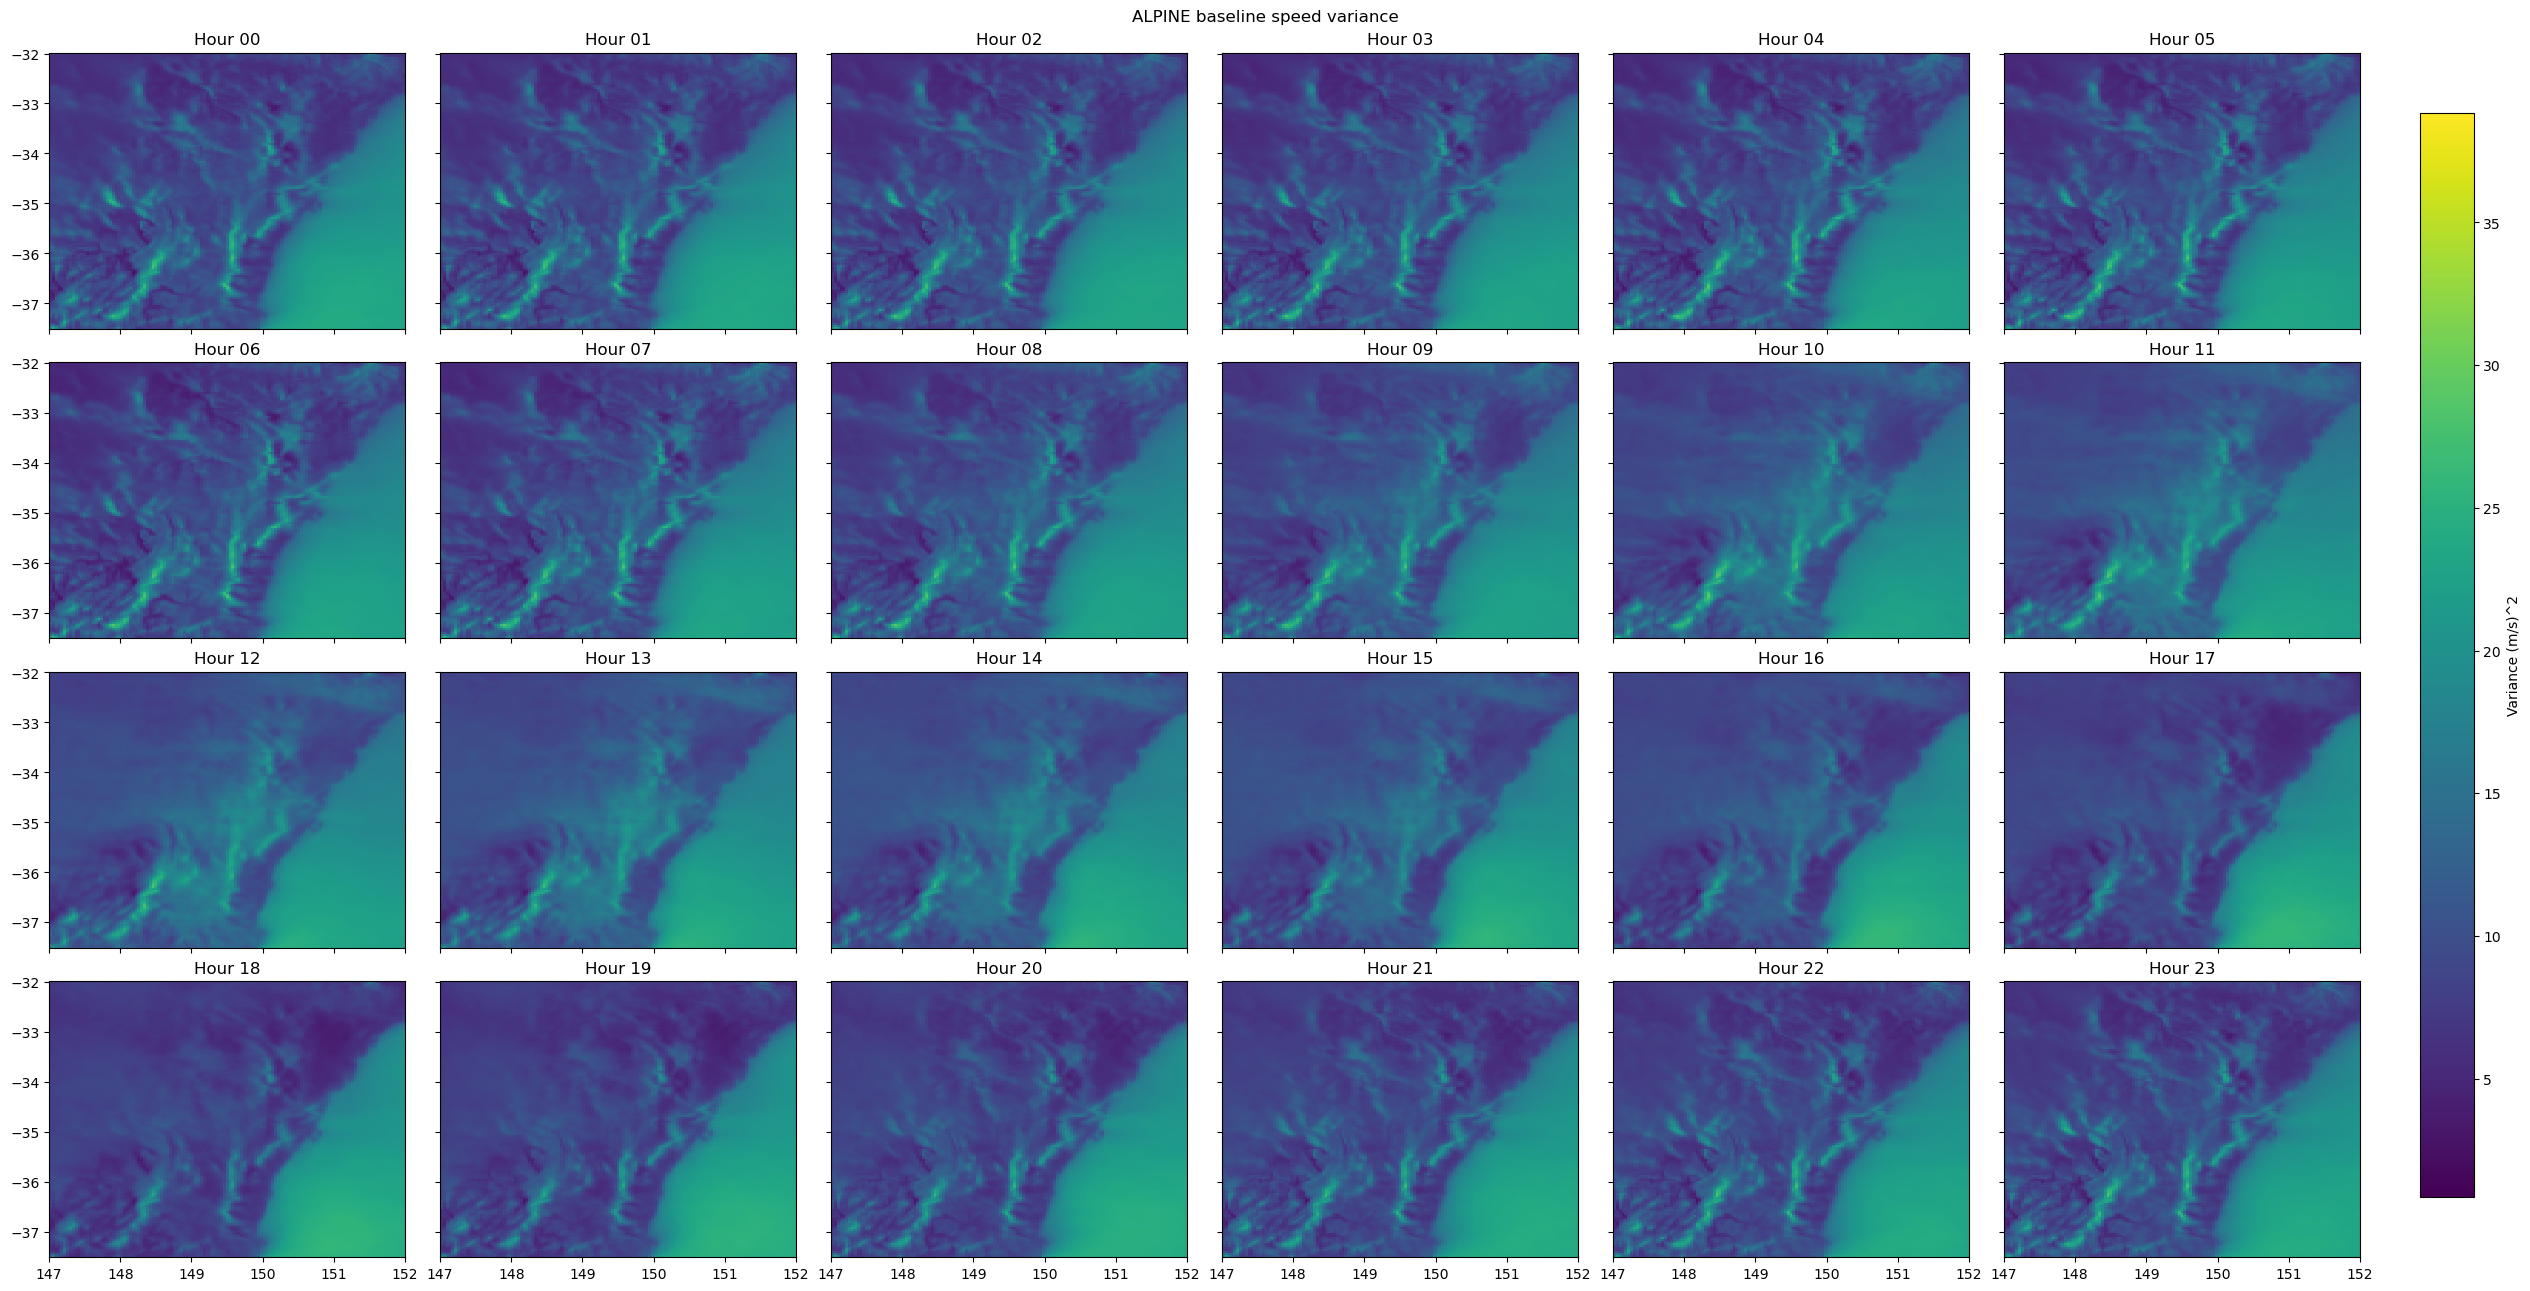

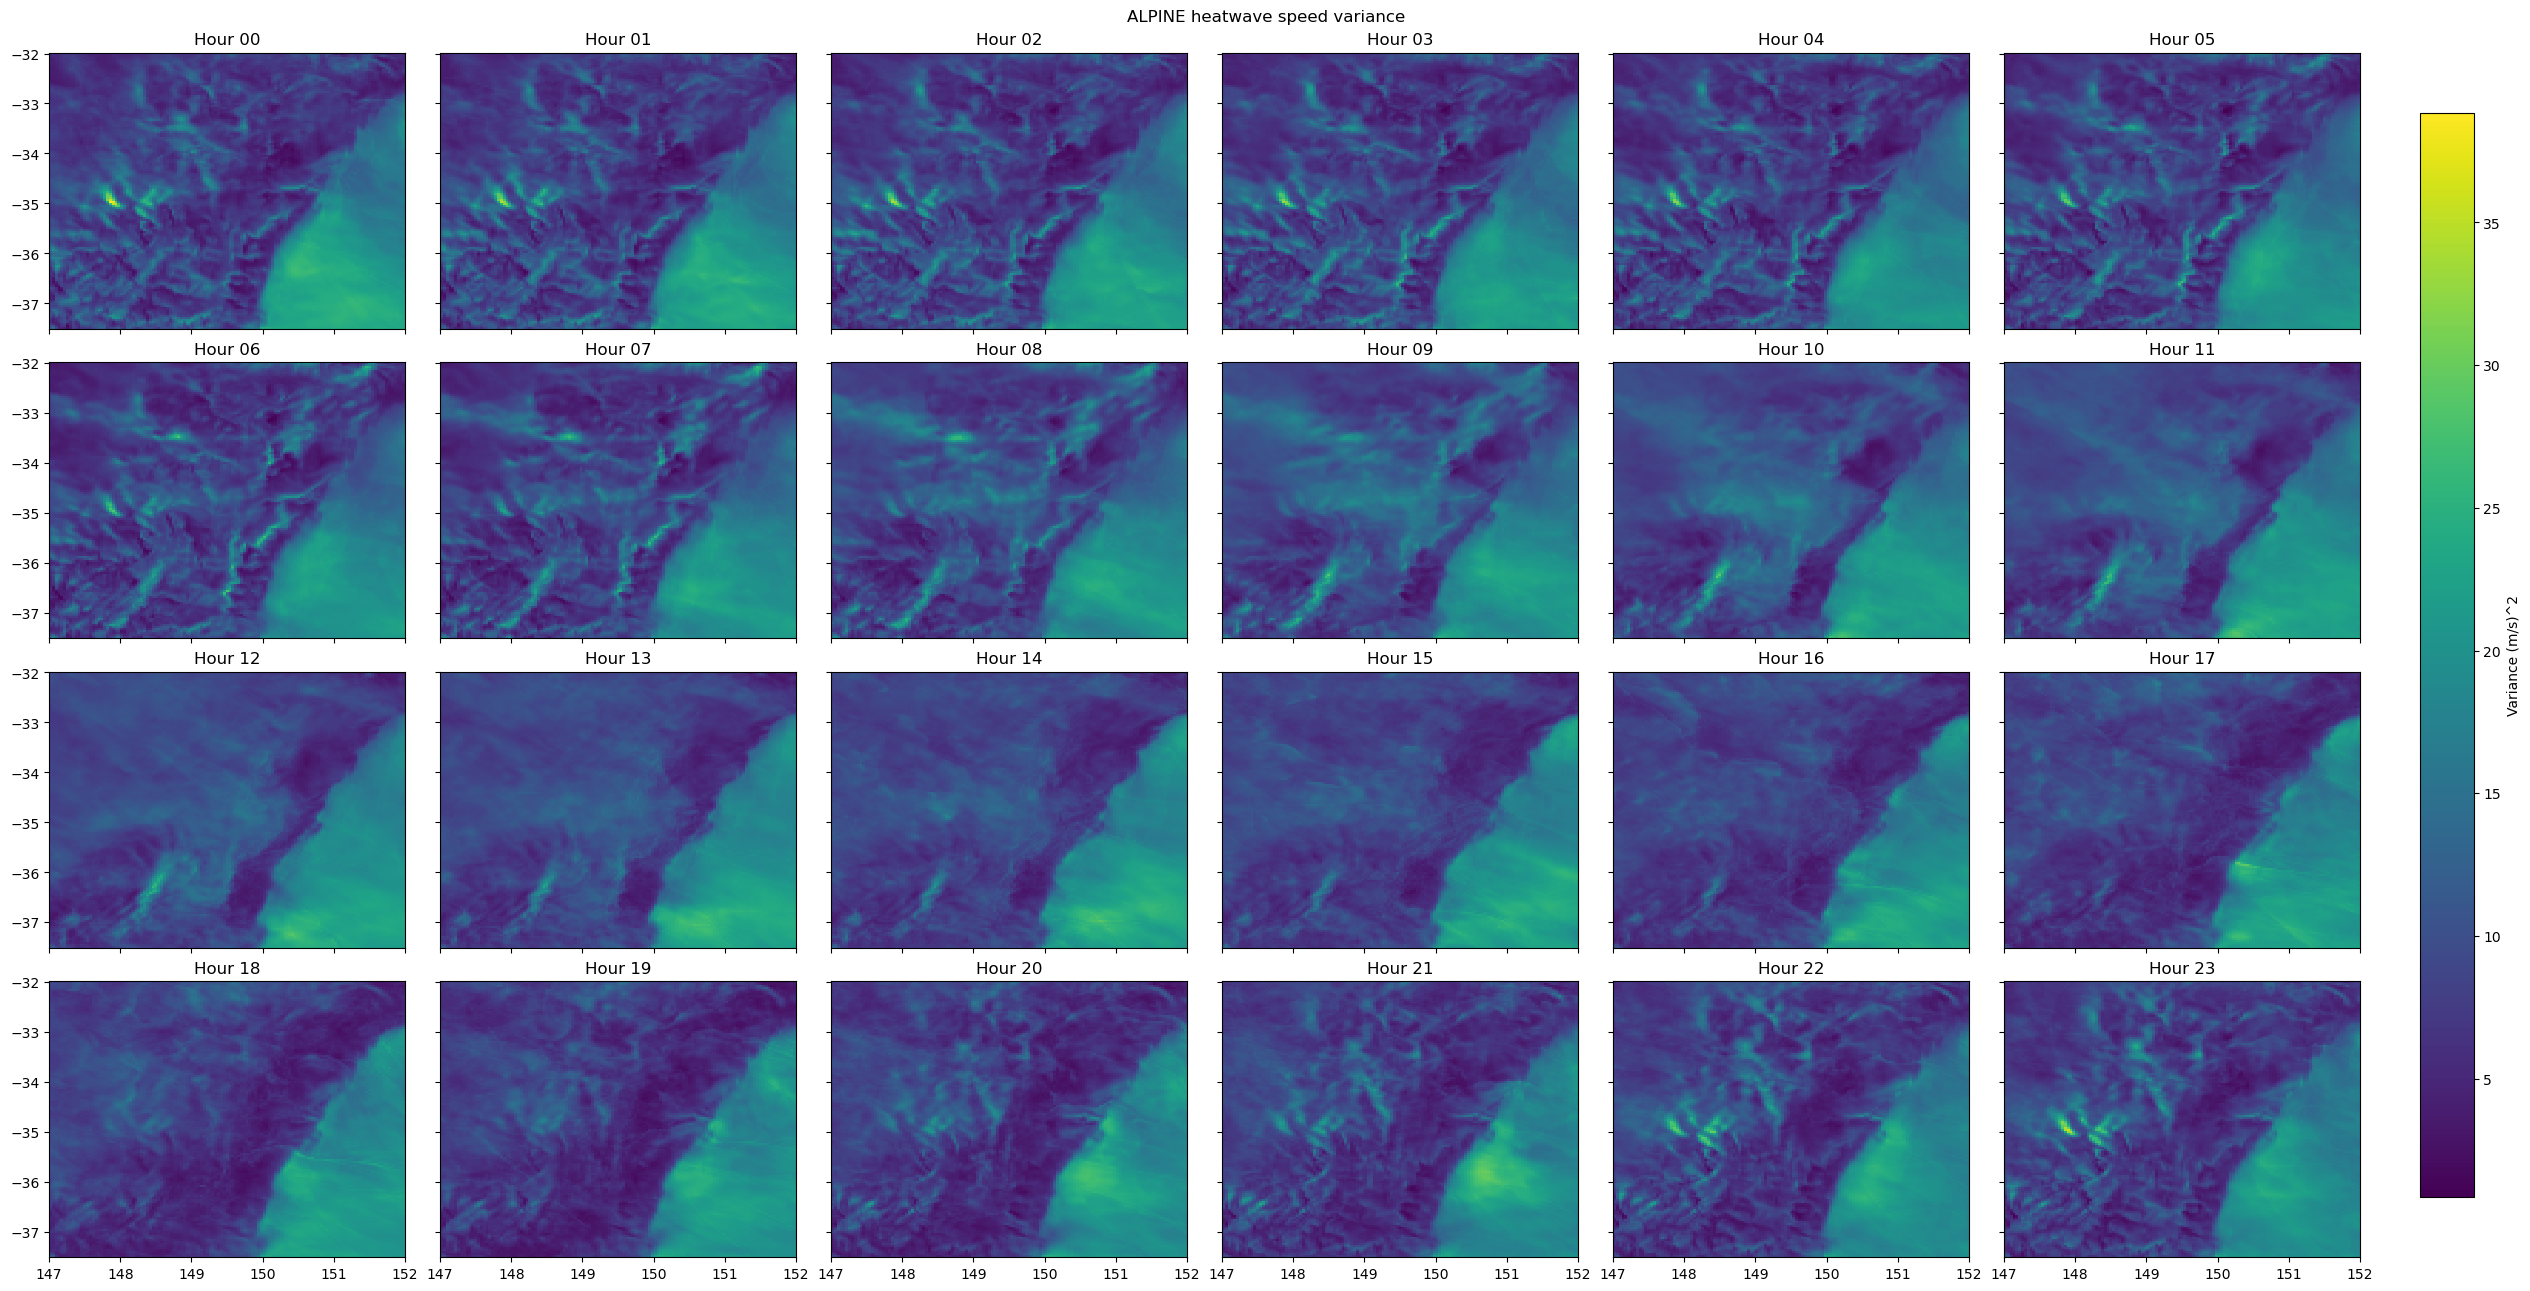

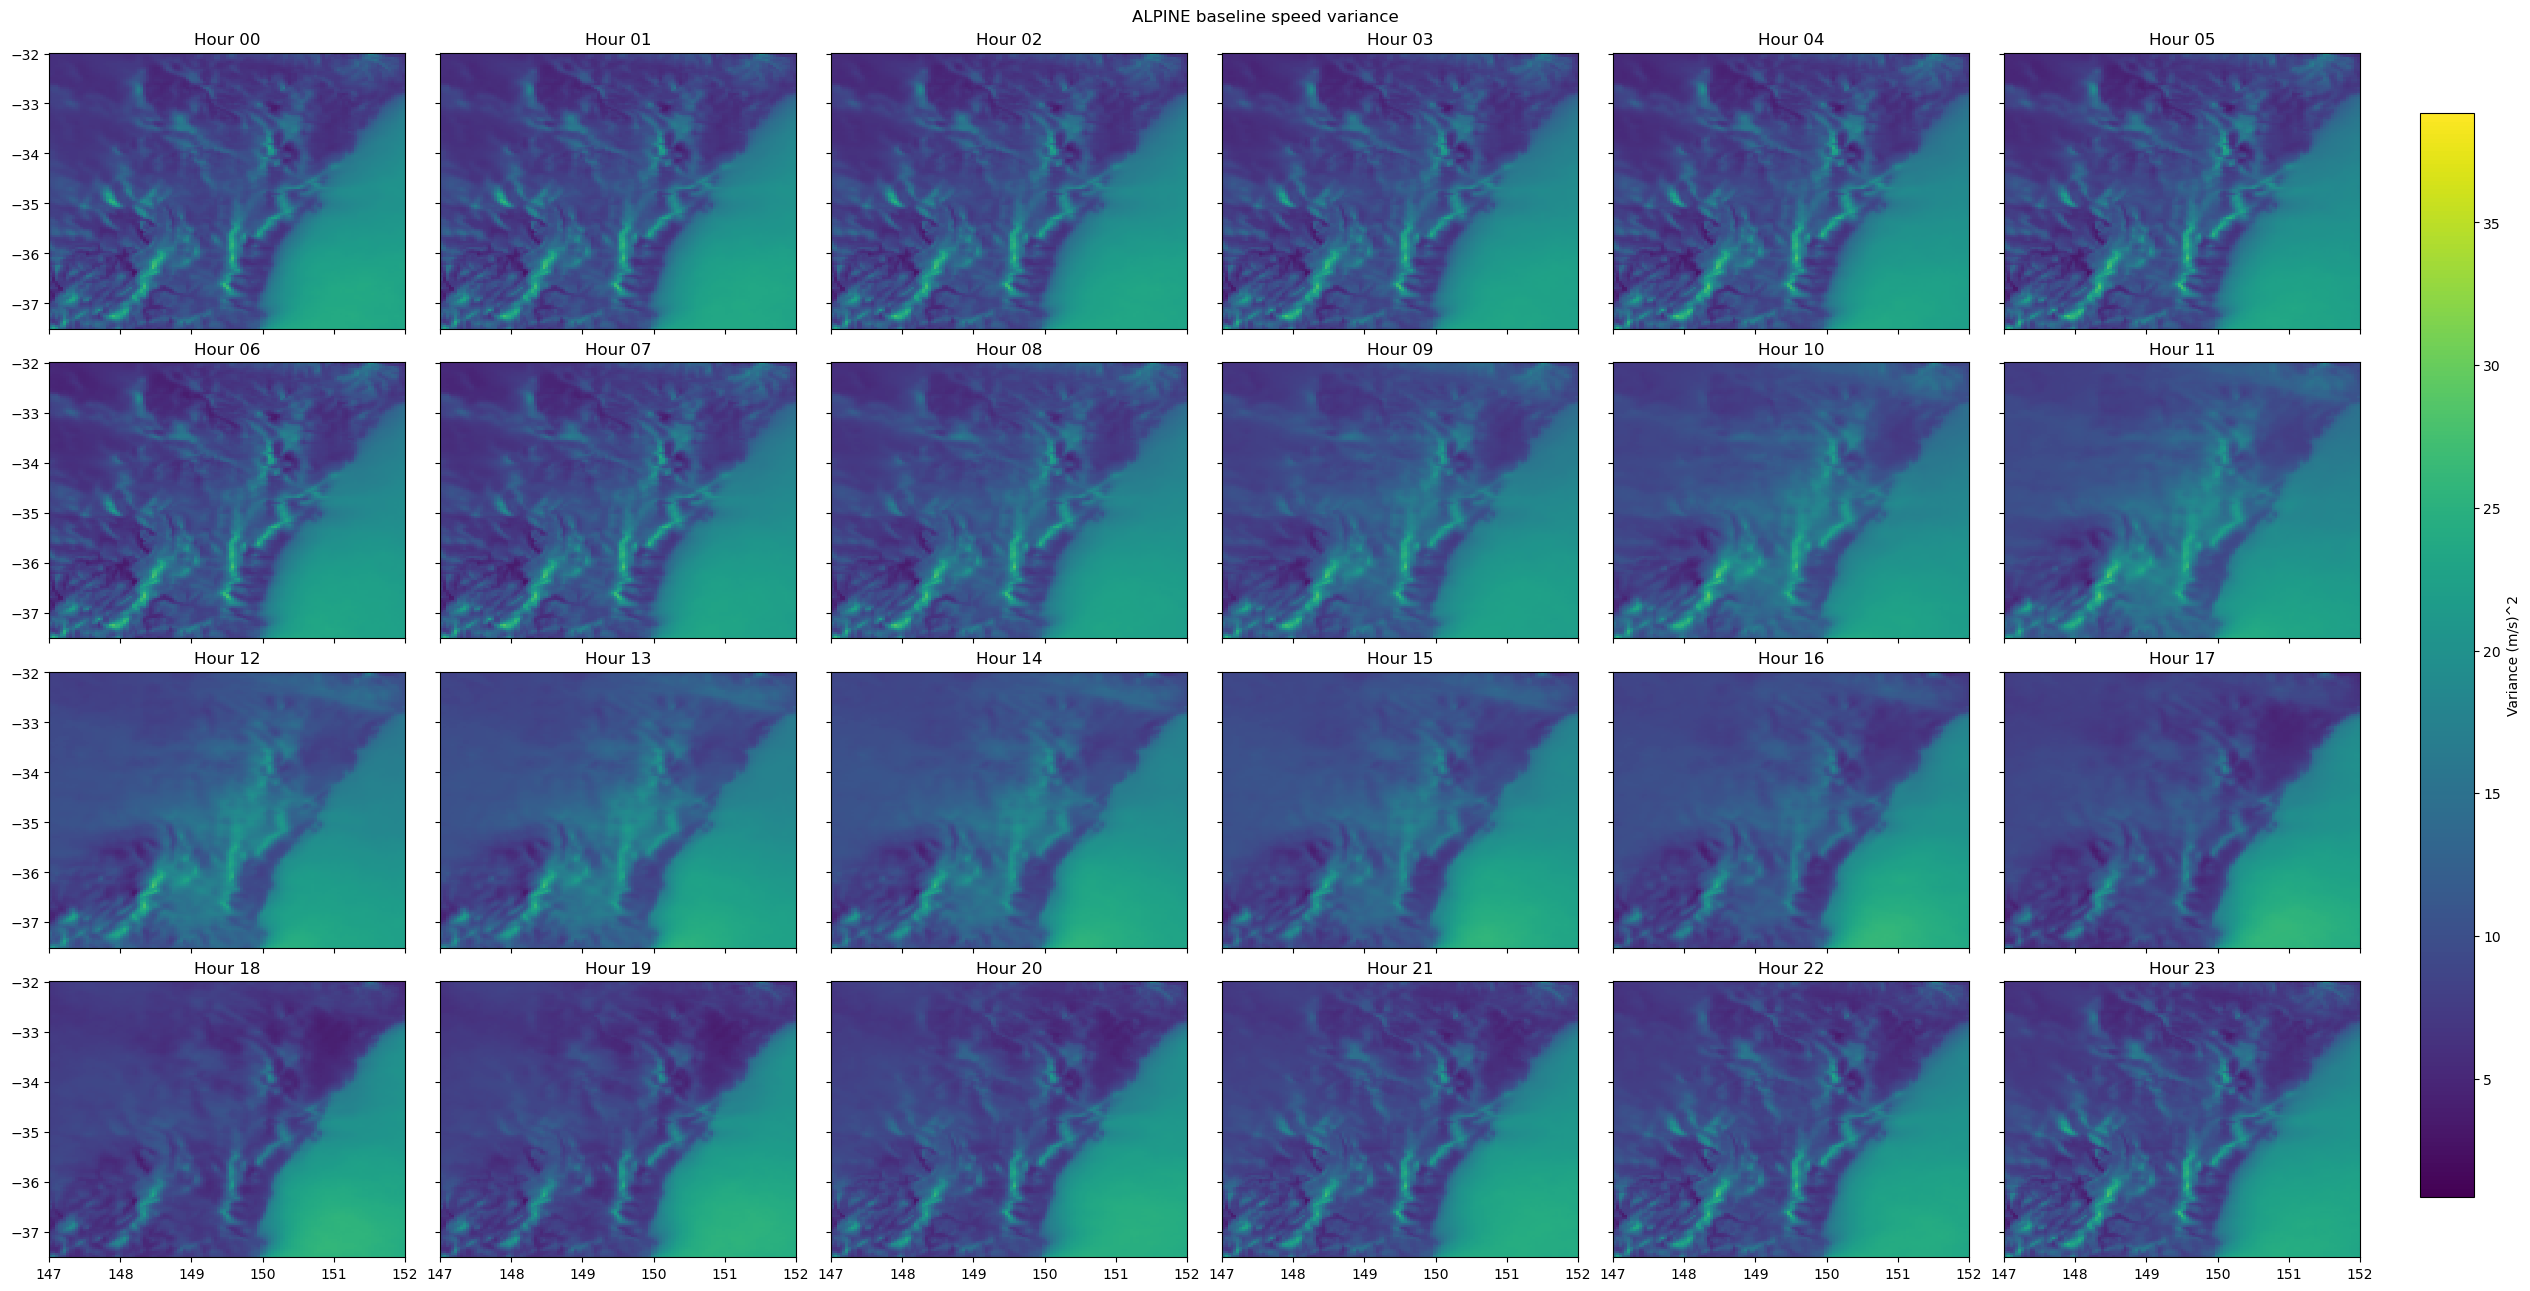

In [5]:
def plot_variance_facets(data_array, title, cmap='viridis', ncols=6, vmin=None, vmax=None):
    if 'hour' not in data_array.dims:
        raise ValueError("Expected an 'hour' dimension for faceted variance plots.")

    data_array = data_array.transpose('hour', 'lat', 'lon')

    if vmin is None:
        vmin = float(data_array.min())
    if vmax is None:
        vmax = float(data_array.max())

    n_hours = data_array.sizes['hour']
    ncols = max(1, ncols)
    nrows = int(np.ceil(n_hours / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    last_plot = None
    for idx, hour in enumerate(data_array['hour'].values):
        ax = axes[idx]
        last_plot = data_array.sel(hour=hour).plot(
            ax=ax,
            x='lon',
            y='lat',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
        )
        ax.set_title(f'Hour {int(hour):02d}')
        ax.set_xlabel('')
        ax.set_ylabel('')

    for ax in axes[n_hours:]:
        ax.set_visible(False)

    cbar = fig.colorbar(last_plot, ax=axes[:n_hours], shrink=0.9, pad=0.02)
    cbar.set_label('Variance (m/s)^2')
    fig.suptitle(title)
    return fig


var_vmin = float(min(summary['hw_speed_var'].min(), summary['bl_speed_var'].min()))
var_vmax = float(max(summary['hw_speed_var'].max(), summary['bl_speed_var'].max()))

hw_var_fig = plot_variance_facets(
    summary['hw_speed_var'],
    title=f"{area.upper()} heatwave speed variance",
    cmap='viridis',
    ncols=6,
    vmin=var_vmin,
    vmax=var_vmax,
)

bl_var_fig = plot_variance_facets(
    summary['bl_speed_var'],
    title=f"{area.upper()} baseline speed variance",
    cmap='viridis',
    ncols=6,
    vmin=var_vmin,
    vmax=var_vmax,
)

hw_var_fig.savefig(
    f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/{area}_wind/{area}_hw_speed_variance.png",
    dpi=150,
    bbox_inches='tight',
)
bl_var_fig.savefig(
    f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/{area}_wind/{area}_bl_speed_variance.png",
    dpi=150,
    bbox_inches='tight',
)

hw_var_fig
bl_var_fig